## Rotary Power Spectra and CTD Profiles near Terra Nova Bay 

### Rotary Power Spectra 

**Goal:** Apply correlation and spectral relations to a vector timeseries (i.e. ocean currents) that is influenced by Earth's rotation. Earth's rotation can cause an asymmetry in fourier coefficients and we seek statistical relations that are invariant to rotation. 

A given velocity can be decomposed into a real and imaginary part, 

$$ u = u + iv $$

where $ i = \sqrt{-1} $

In Gonella (1972), four quantities are deemed useful: 

1. The mean kinetic energy (i.e. the total spectrum)

2. The rotary coefficient 

3. The orientation of the ellipse 

4. The stability of the ellipse 

Expanding on these, 

The mean kinetic energy, or the total spectrum, is defined as the summation of the clockwise ($ S_{-} $) and counterclockwise ($ S_{+} $) spectrums, 

$$ S_{t} = S_{-} + S_{+} $$

The rotary coefficient is defined as, 

$$ C_{R} = (S_{-} - S_{+}) / (S_{-} + S_{+}) $$



In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, csd
import pandas as pd
from TNB_tools.spectra import rotary_power_spectra
import gsw


In [83]:
# load in TNBD current meter data from bottom sensor (~1130 meters)
# # MAC
vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

# DELL
# vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc")


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\mackenzie\\Documents\\Research\\PhD\\TNB_tools\\MastersThesis\\tnbd_2018_vel_bot_1093.nc'

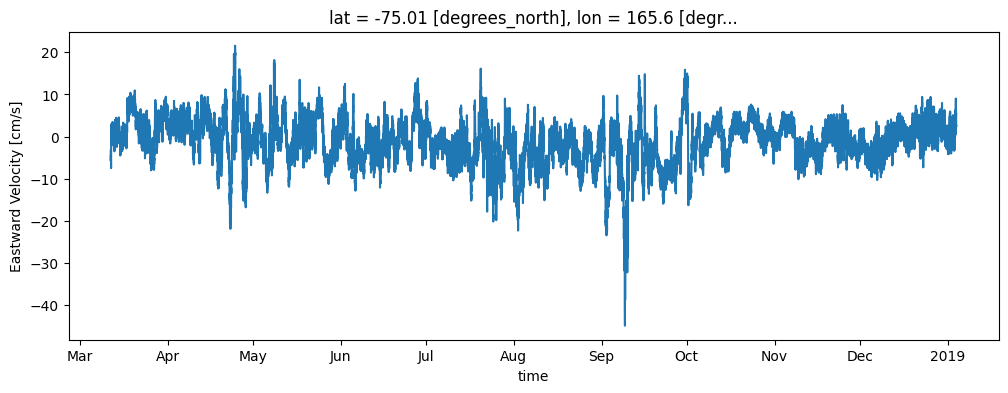

In [3]:
vel.u.plot(figsize=(12,4))

In [4]:
f = gsw.f(-75)
# intertial frequency [cpd]
f_inertial = np.abs(f) * 86400 / (2*np.pi)

In [5]:
f

-0.0001408728441353982

In [6]:
# step 1: define u, v, fs, and nperseg (to be used in power spectra calculation)
u = vel.u
v= vel.v
fs = 1/900 # 15 minutes
nperseg = 1024

# other nperseg values to try: 
# 5722 --> 5 segments 
# 4096 --> 13 segments 
# 2048 --> 27 segments 
# 1024 --> 55 segments 

In [7]:
# Chi - squared CI workflow 
freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

Text(0.38, 1.02, 'K1')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/88943626.py:16: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


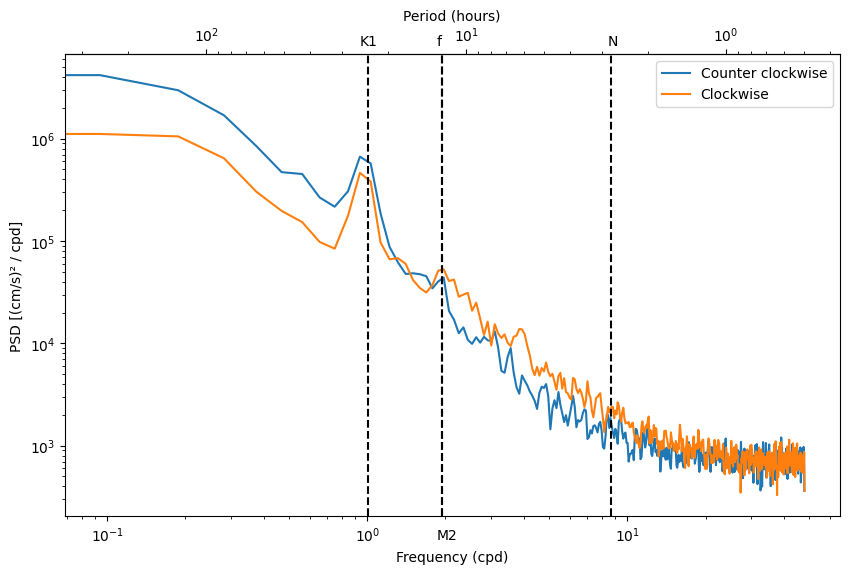

In [8]:
fig = plt.figure(figsize=(10,6))
plt.loglog(freq * 86400, S_ccw, label='Counter clockwise')
plt.loglog(freq * 86400, S_cw,  label='Clockwise')
# plt.loglog(freq * 86400, (S_ccw + S_cw), label='Total')
plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

# Grab the current axis to add the secondary axis
ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k',label='M2',ls='--')
plt.axvline(1.0027, color='k',label='K1',ls='--')
plt.axvline(1e-4*86400, color='k',label='N',ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

Text(0.38, 1.02, 'K1')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2558768422.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


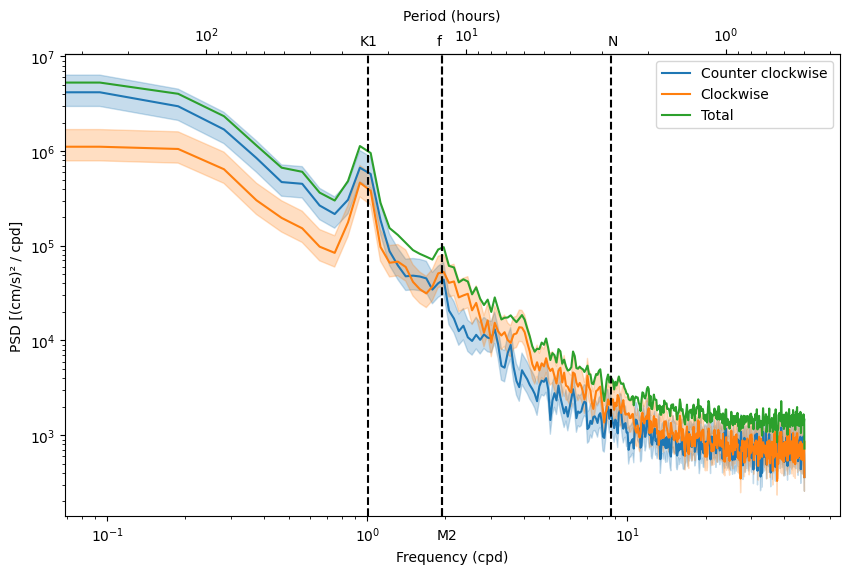

In [9]:
# compute spectra + CI first
# freq, Suu, Svv, Cuv = auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
# S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)

# dof, L = dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
# S_ccw_lo, S_ccw_hi = spectra_chi2_ci(S_ccw, dof)
# S_cw_lo, S_cw_hi = spectra_chi2_ci(S_cw, dof)

fig = plt.figure(figsize=(10,6))

freq_cpd = freq * 86400  # compute once, reuse for lines + shading

l1, = plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.fill_between(freq_cpd, S_ccw_lo, S_ccw_hi, color=l1.get_color(), alpha=0.25)

l2, = plt.loglog(freq_cpd, S_cw, label='Clockwise')
plt.fill_between(freq_cpd, S_cw_lo, S_cw_hi, color=l2.get_color(), alpha=0.25)

plt.loglog(freq_cpd, (S_ccw + S_cw), label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k', label='M2', ls='--')
plt.axvline(1.0027, color='k', label='K1', ls='--')
plt.axvline(1e-4*86400, color='k', label='N', ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

In [10]:
S_total = S_ccw + S_cw

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2797038303.py:17: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


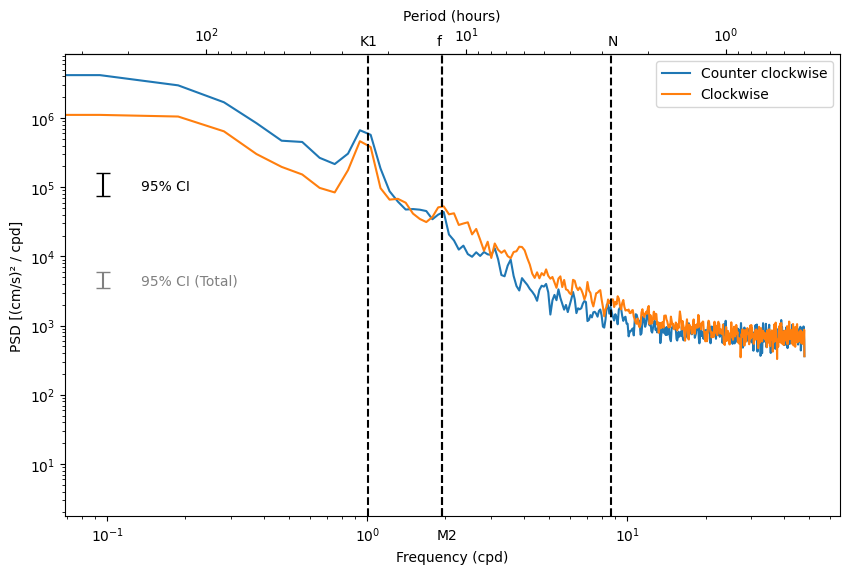

In [11]:
fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

In [12]:
# calculate rotary coefficient and ellipse orientation 
Cr = rotary_power_spectra.rotary_coefficient(S_ccw,S_cw)

In [13]:
sigma = np.arange(10e-2, 10e1, 0.01)
Cr_theory = rotary_power_spectra.rotary_coefficient_theory(sigma,-f_inertial)

In [14]:
f_inertial

1.937140660071021

In [15]:
Cr_theory

array([-0.10297055, -0.11320442, -0.12342033, ..., -0.03873989,
       -0.03873602, -0.03873215])

In [16]:
theta = rotary_power_spectra.ellipse_orientation(Suu,Svv,Cuv)

Text(0.5, 0, 'Freqeuncy [cpd]')

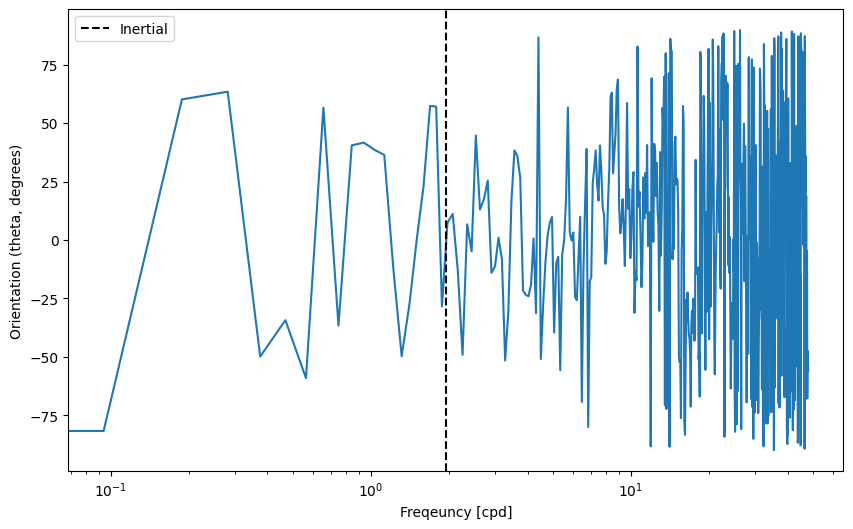

In [17]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, theta)

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Orientation (theta, degrees)')
plt.xlabel('Freqeuncy [cpd]')

Text(0.5, 0, 'Freqeuncy [cpd]')

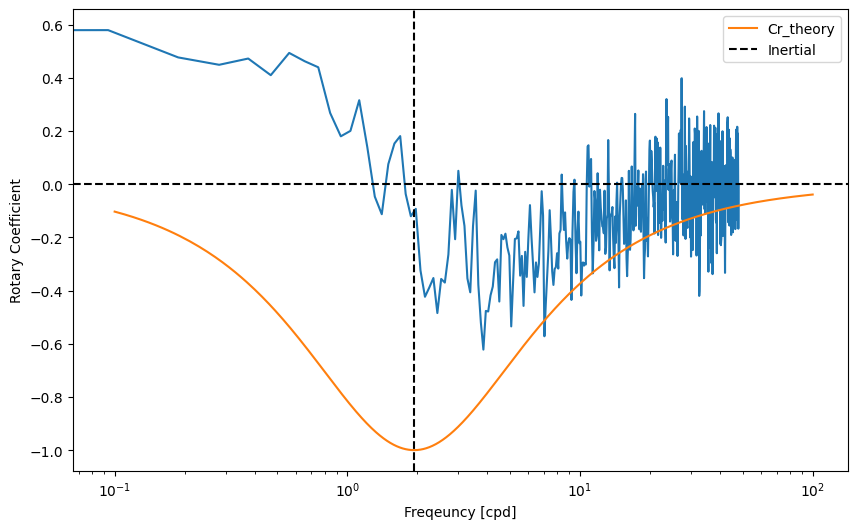

In [18]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, Cr)
plt.semilogx(sigma, Cr_theory,label='Cr_theory')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axhline(0, color='k', ls='--')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Rotary Coefficient')
plt.xlabel('Freqeuncy [cpd]')

### Seasonal Spectra 

In [19]:
# time slices for seasonal averages 
MAM = slice('2018-03','2018-05')
JJA = slice('2018-06','2018-08')
SON = slice('2018-09','2018-11')
DJF = slice('2018-12','2019-01')  # note only december data here 



In [20]:
MAM_subset = vel.sel(time=MAM)
JJA_subset = vel.sel(time=JJA)
SON_subset = vel.sel(time=SON)
DJF_subset = vel.sel(time=DJF)

In [21]:
len(MAM_subset.time), len(JJA_subset.time), len(SON_subset.time), len(DJF_subset.time)

(7776, 8832, 8736, 3266)

In [22]:
nperseg = len(DJF_subset.time)//2

In [23]:
nperseg

1633

In [24]:
2 ** int(np.log2(nperseg))

1024

In [25]:
nperseg = 2 ** int(np.log2(nperseg))

In [26]:
nperseg

1024

In [27]:
# # MAM SPECTRA 
# freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(MAM_subset.u, MAM_subset.v, fs, nperseg=nperseg, noverlap=0)
# S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

# dof, L = rotary_power_spectra.dof_welch(n=len(MAM_subset.u), nperseg=nperseg, noverlap=0)
# S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
# S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

# S_total = S_ccw + S_cw

In [28]:
%matplotlib widget

Text(0.5, 1.0, 'MAM Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/1163513702.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


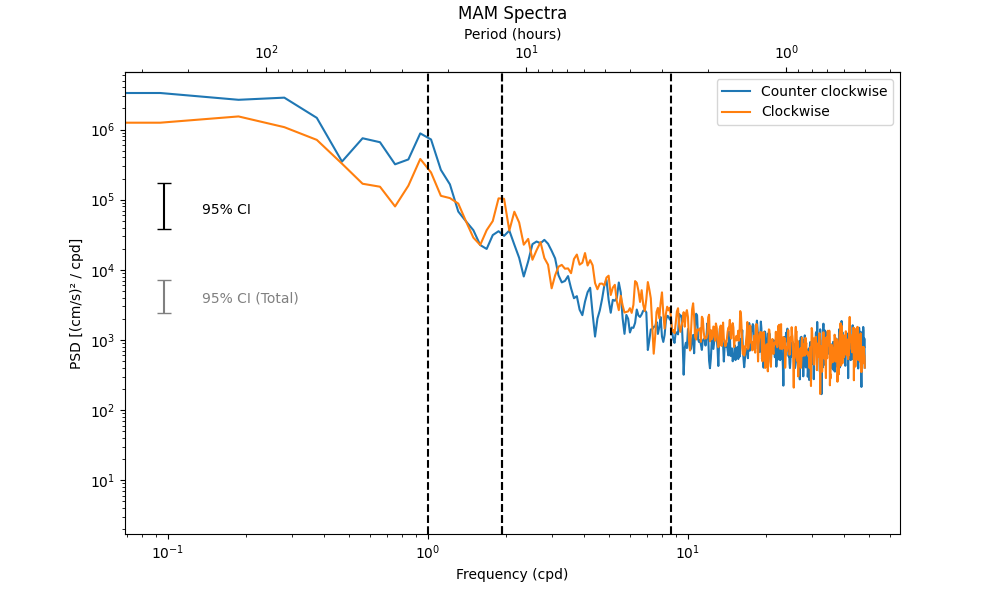

In [29]:
# -------------------- MAM SPECTRA --------------------------------
# nperseg = len(MAM_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(MAM_subset.u, MAM_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(MAM_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('MAM Spectra')

Text(0.5, 1.0, 'JJA Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/137673942.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


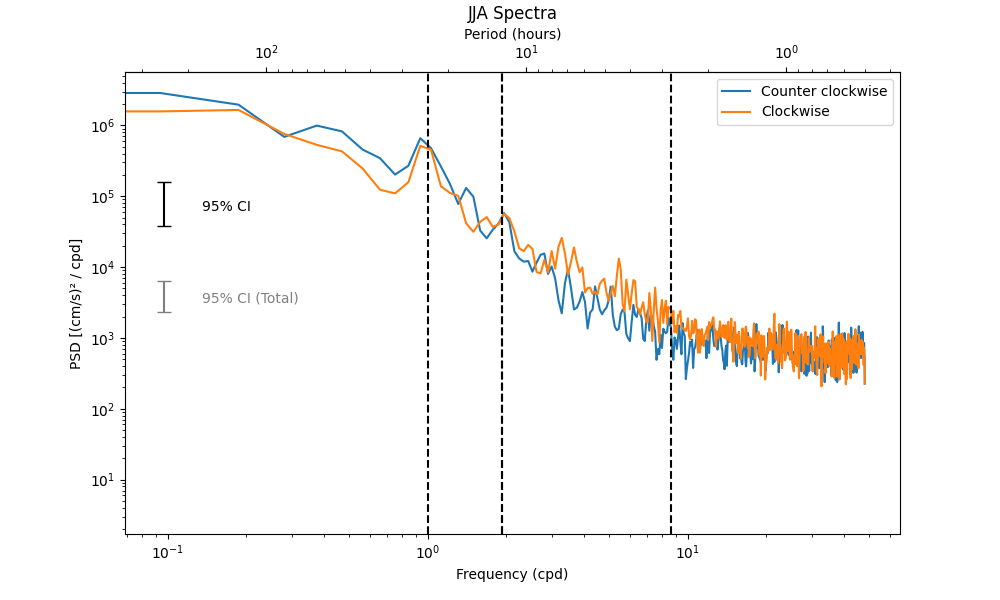

In [30]:
# -------------------- JJA SPECTRA --------------------------------
# nperseg = len(JJA_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(JJA_subset.u, JJA_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(JJA_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('JJA Spectra')

Text(0.5, 1.0, 'SON Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2146110324.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


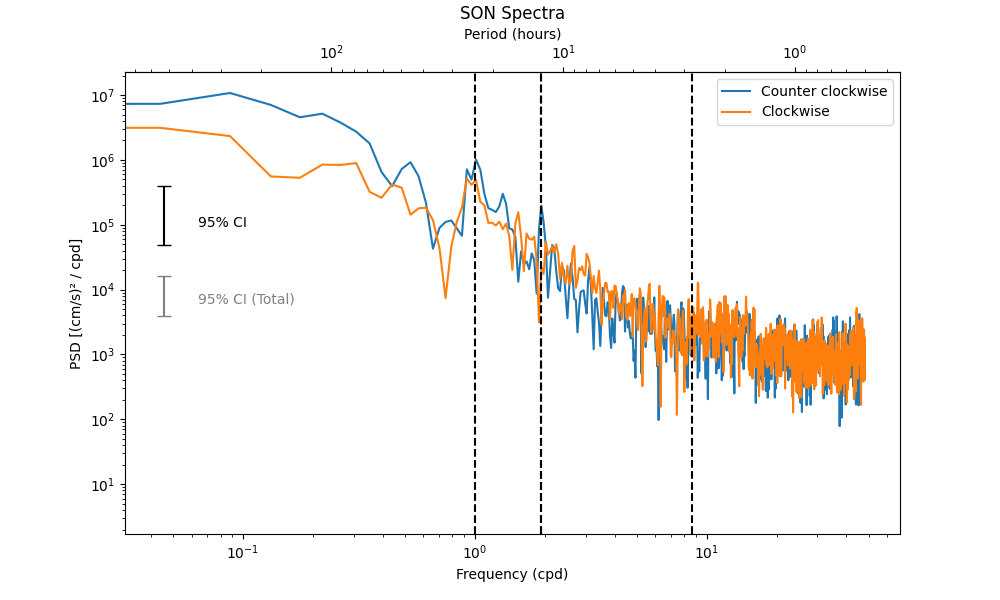

In [31]:
# -------------------- SON SPECTRA --------------------------------
nperseg = len(SON_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(SON_subset.u, SON_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(SON_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('SON Spectra')

Text(0.5, 1.0, 'DJF Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2722115822.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


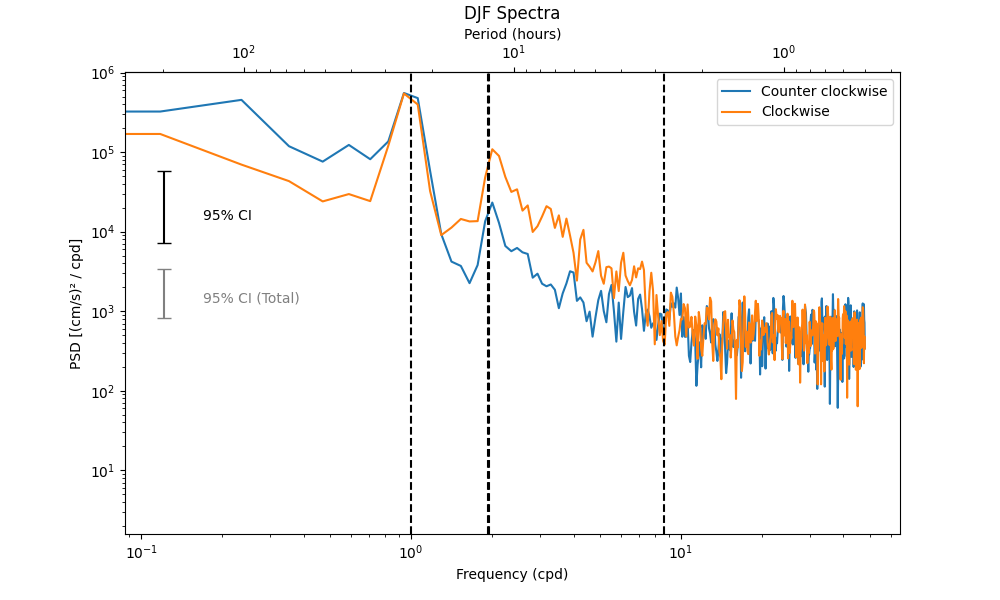

In [32]:
# -------------------- DJF SPECTRA --------------------------------
nperseg = len(DJF_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(DJF_subset.u, DJF_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(DJF_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('DJF Spectra')

In [33]:
dof

8.0

In [34]:
welch?

Signature:
welch(
    x,
    fs=1.0,
    window='hann',
    nperseg=None,
    noverlap=None,
    nfft=None,
    detrend='constant',
    return_onesided=True,
    scaling='density',
    axis=-1,
    average='mean',
)
Docstring:
Estimate power spectral density using Welch's method.

Welch's method [1]_ computes an estimate of the power spectral
density by dividing the data into overlapping segments, computing a
modified periodogram for each segment and averaging the
periodograms.

Parameters
----------
x : array_like
    Time series of measurement values
fs : float, optional
    Sampling frequency of the `x` time series. Defaults to 1.0.
window : str or tuple or array_like, optional
    Desired window to use. If `window` is a string or tuple, it is
    passed to `get_window` to generate the window values, which are
    DFT-even by default. See `get_window` for a list of windows and
    required parameters. If `window` is array_like it will be used
    directly as the window and its lengt

### All Moorings 

In [ ]:
# load in DITD and D data - MAC
# DITD_vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/vel_1100.nc')

# TNBD_vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

# moorings = xr.open_datatree('/Users/mackenzie/Documents/Research/PhD/TNB_tools/preprocess/TNB_Moorings_DataTree.nc')

In [2]:
# Load in data - DELL 

TNBD_vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc")

DITD_vel = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/DITD_2018_2019/vel_1100.nc')

moorings = xr.open_datatree('/Users/mblan/Documents/research/TNB_tools/examples/TNB_Moorings_DataTree.nc')

In [3]:
# fix DITD time - should save this change permenantly later
DITD_vel['time'] = DITD_vel.time - pd.Timedelta(12,'h')

In [4]:
# rename variables in DITD velocity dataset 
DITD_vel = DITD_vel.rename({
    'east':'u',
    'north':'v',
    'up':'w',
    'pressure':'pres',
    'direction':'dir'
}).assign_coords({
    'z':1121,
    'lat':-75.28,
    'lon':164.1
})
# # rename variables in DITD velocity dataset 
# DITD_vel_bot = DITD_vel_bot.rename({
#     'east':'u',
#     'north':'v',
#     'up':'w',
#     'pressure':'pres',
#     'direction':'dir'
# }).assign_coords({
#     'z':1218,
#     'lat':-75.28,
#     'lon':164.1
# })

In [5]:
D_vel = moorings['D/2017/vel/bot'].to_dataset().sel(time=slice('2018-01-01','2018-12-31'))

TNBD sampling interval is 15 min. DITD sampling interval is 10 min. D sampling interval is 30 min

In [6]:
DITD_vel['u'] = DITD_vel.u * 100
DITD_vel['v'] = DITD_vel.v * 100

In [7]:
# estimate rotary power spectra for each mooring 

In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# from TNB_tools.spectra import rotary_power_spectra
from TNB_tools.spectra.rotary_power_spectra import (
    auto_cross_spectra,
    rotary_components,
    rotary_coefficient,
    dof_welch,
    chi2_ci_multiplier,
    add_ci_bracket,
)

# Mooring registry — update fs once you confirm sampling intervals
# from ds.time.diff('time').median()
moorings = {
    'TNBD': {'ds': TNBD_vel, 'fs': 1/900,  'color': 'steelblue', 'label': 'TNBD'},
    'DITD': {'ds': DITD_vel, 'fs': 1/600,  'color': 'tomato',    'label': 'DITD'},
    'D':    {'ds': D_vel,    'fs': 1/1800,  'color': 'seagreen',  'label': 'D'},
}

# Confirm sampling intervals
for name, m in moorings.items():
    dt = m['ds'].time.diff('time').median().values / np.timedelta64(1, 's')
    print(f"{name}: dt = {dt:.0f} s  (fs = {1/dt:.6f} Hz)")

TNBD: dt = 900 s  (fs = 0.001111 Hz)
DITD: dt = 600 s  (fs = 0.001667 Hz)
D: dt = 1800 s  (fs = 0.000556 Hz)


In [9]:
# nperseg fixed across all moorings so frequency resolution is comparable.
# Chosen so even the shortest record (D, 17520 samples) gets ~8 segments.
# D:    17520 // 8 = 2190 -> round to 2048
# TNBD: 28610 // 2048 = 13 segments, dof = 26
# DITD: 42912 // 2048 = 20 segments, dof = 40
# D:    17520 // 2048 =  8 segments, dof = 16
NPERSEG = 2048

spectra_full = {}

for name, m in moorings.items():
    ds   = m['ds']
    fs   = m['fs']
    u    = ds['u'].values
    v    = ds['v'].values
    n    = len(u)

    freq, Suu, Svv, Cuv = auto_cross_spectra(
        u, v, fs=fs, nperseg=NPERSEG, noverlap=0
    )
    S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)
    Cr           = rotary_coefficient(S_ccw, S_cw)
    dof, L       = dof_welch(n, NPERSEG, noverlap=0)
    f_lo, f_hi   = chi2_ci_multiplier(dof, ci=95)

    spectra_full[name] = {
        'freq':  freq * 86400,   # convert to cpd
        'S_ccw': S_ccw,
        'S_cw':  S_cw,
        'Cr':    Cr,
        'dof':   dof,
        'L':     L,
        'f_lo':  f_lo,
        'f_hi':  f_hi,
    }
    print(f"{name}: n={n}, L={L}, dof={dof}, f_lo={f_lo:.2f}, f_hi={f_hi:.2f}")

TNBD: n=28610, L=13, dof=26, f_lo=0.62, f_hi=1.88
DITD: n=42912, L=20, dof=40, f_lo=0.67, f_hi=1.64
D: n=17520, L=8, dof=16, f_lo=0.55, f_hi=2.32


In [10]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

C:\Users\mblan\AppData\Local\Temp\ipykernel_63428\3964837487.py:31: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
C:\Users\mblan\AppData\Local\Temp\ipykernel_63428\3964837487.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


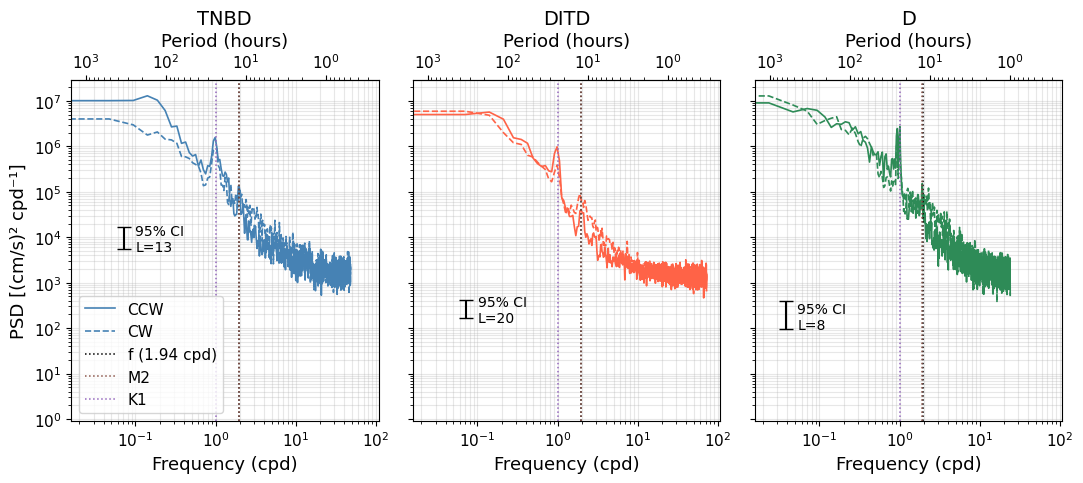

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True, sharex=True, constrained_layout=True)

# Reference lines — inertial freq at TNB latitude (~-74.9°S) and M2 tidal
import gsw
lat      = -74.9
f_iner   = np.abs(gsw.f(lat)) * 86400 / (2 * np.pi)   # cpd
f_M2     = 1.9322                                        # cpd
f_diurn  = 1.0                                           # cpd

for ax, (name, sp) in zip(axes, spectra_full.items()):
    freq  = sp['freq']
    color = moorings[name]['color']

    ax.loglog(freq, sp['S_ccw'], color=color,  label='CCW', linewidth=1.2)
    ax.loglog(freq, sp['S_cw'],  color=color,  label='CW',  linewidth=1.2,
              linestyle='--')

    # Reference frequency lines
    ax.axvline(f_iner,  color='k',  linestyle=':',  linewidth=1.1, label=f'f ({f_iner:.2f} cpd)')
    ax.axvline(f_M2,    color='tab:brown', linestyle=':',  linewidth=1.1, label='M2')
    ax.axvline(f_diurn, color='tab:purple',   linestyle=':',  linewidth=1.1, label='K1')

    add_ci_bracket(ax, sp['f_lo'], sp['f_hi'],
                   label=f"95% CI\nL={sp['L']}", color='k', x_frac=0.1, y_frac=0.3)

    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Frequency (cpd)')
    ax.grid(True, which='both', alpha=0.3)

    # Secondary period axis
    secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')

axes[0].set_ylabel('PSD [(cm/s)² cpd⁻¹]')
axes[0].legend()

# plt.suptitle('Rotary power spectra — full record', y=1.02)
plt.tight_layout()
# plt.savefig('moorings_2018_fullspectra.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\mblan\AppData\Local\Temp\ipykernel_63428\3724191257.py:20: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
C:\Users\mblan\AppData\Local\Temp\ipykernel_63428\3724191257.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


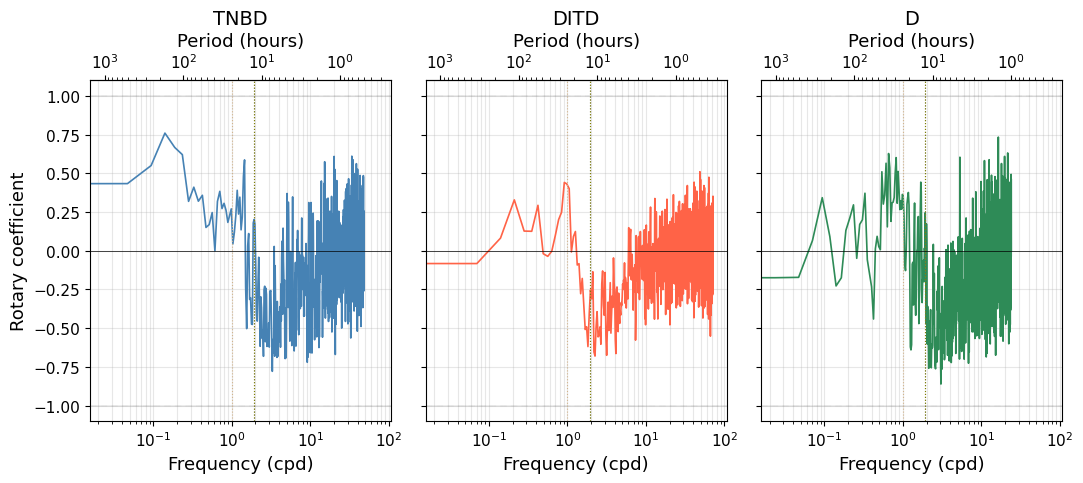

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True, sharex=True, constrained_layout=True)

for ax, (name, sp) in zip(axes, spectra_full.items()):
    freq  = sp['freq']
    color = moorings[name]['color']

    ax.semilogx(freq, sp['Cr'], color=color, linewidth=1.2)
    ax.axhline(0,  color='k', linewidth=0.5)
    ax.axhline( 1, color='k', linewidth=0.3, linestyle=':')
    ax.axhline(-1, color='k', linewidth=0.3, linestyle=':')
    ax.axvline(f_iner,  color='gray',  linestyle=':', linewidth=0.8)
    ax.axvline(f_M2,    color='olive', linestyle=':', linewidth=0.8)
    ax.axvline(f_diurn, color='tan',   linestyle=':', linewidth=0.8)

    ax.set_ylim(-1.1, 1.1)
    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Frequency (cpd)')
    ax.grid(True, which='both', alpha=0.3)

    secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')

axes[0].set_ylabel('Rotary coefficient')
# plt.suptitle('Rotary coefficient — full record', y=1.02)
plt.tight_layout()
# plt.savefig('moorings_2018_rotarycoefficient.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
seasons = {
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
    'DJF': [12],         # December only
}
season_notes = {
    'MAM': 'Mar–May',
    'JJA': 'Jun–Aug',
    'SON': 'Sep–Nov',
    'DJF': 'Dec only',
}
season_order  = ['MAM', 'JJA', 'SON', 'DJF']
mooring_order = ['TNBD', 'DITD', 'D']

spectra_seasonal = {name: {} for name in mooring_order}

for name in mooring_order:
    ds = moorings[name]['ds']
    fs = moorings[name]['fs']

    for season, months in seasons.items():
        seasonal = ds.sel(time=ds.time.dt.month.isin(months))
        n        = len(seasonal.time)

        if n < NPERSEG:
            print(f"{name} {season}: only {n} samples, skipping")
            continue

        u = seasonal['u'].values
        v = seasonal['v'].values

        freq, Suu, Svv, Cuv = auto_cross_spectra(
            u, v, fs=fs, nperseg=NPERSEG, noverlap=0
        )
        S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)
        dof, L       = dof_welch(n, NPERSEG, noverlap=0)
        f_lo, f_hi   = chi2_ci_multiplier(dof, ci=95)

        spectra_seasonal[name][season] = {
            'freq':        freq * 86400,
            'S_ccw':       S_ccw,
            'S_cw':        S_cw,
            'dof':         dof,
            'L':           L,
            'f_lo':        f_lo,
            'f_hi':        f_hi,
            'season_note': season_notes[season],
        }
        print(f"{name} {season}: n={n}, L={L}, dof={dof}")

TNBD MAM: n=7776, L=3, dof=6
TNBD JJA: n=8832, L=4, dof=8
TNBD SON: n=8736, L=4, dof=8
TNBD DJF: n=2976, L=1, dof=2
DITD MAM: n=11880, L=5, dof=10
DITD JJA: n=13248, L=6, dof=12
DITD SON: n=13104, L=6, dof=12
DITD DJF: n=4464, L=2, dof=4
D MAM: n=4416, L=2, dof=4
D JJA: n=4416, L=2, dof=4
D SON: n=4368, L=2, dof=4
D DJF: only 1488 samples, skipping


C:\Users\mblan\AppData\Local\Temp\ipykernel_63428\3118049106.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


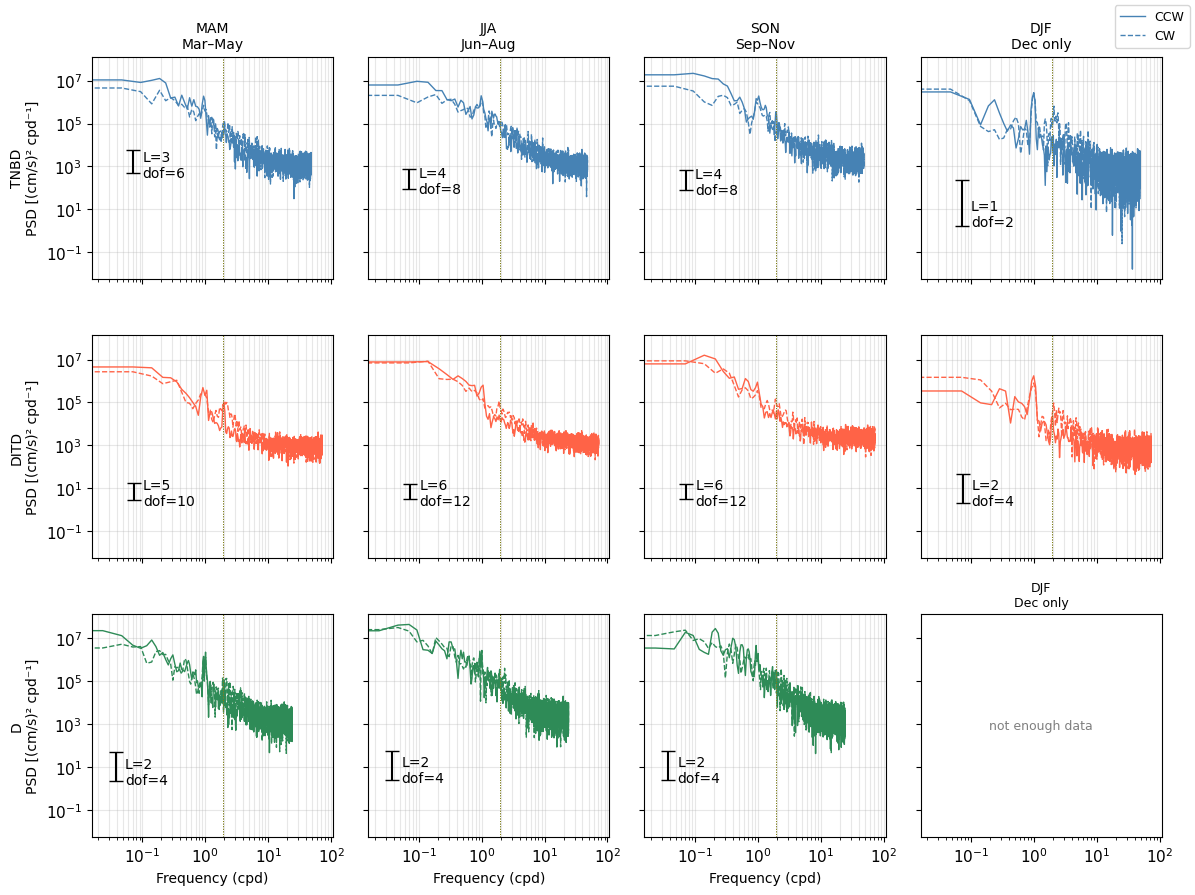

In [14]:
fig, axes = plt.subplots(
    len(mooring_order), len(season_order),
    figsize=(12, 9),
    sharey=True, sharex=True, constrained_layout=True
)

for row, name in enumerate(mooring_order):
    color = moorings[name]['color']
    for col, season in enumerate(season_order):
        ax = axes[row, col]

        if season not in spectra_seasonal[name]:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes,
                    ha='center', va='center', color='gray', fontsize=9)
            ax.set_title(f"{season}\n{season_notes[season]}", fontsize=9)
            continue

        sp   = spectra_seasonal[name][season]
        freq = sp['freq']

        ax.loglog(freq, sp['S_ccw'], color=color, linewidth=1.0, label='CCW')
        ax.loglog(freq, sp['S_cw'],  color=color, linewidth=1.0, label='CW',
                  linestyle='--')

        ax.axvline(f_iner,  color='gray',  linestyle=':', linewidth=0.7)
        ax.axvline(f_M2,    color='olive', linestyle=':', linewidth=0.7)

        add_ci_bracket(ax, sp['f_lo'], sp['f_hi'], color='k',
                       label=f"L={sp['L']}\ndof={sp['dof']}",x_frac=0.1, y_frac=0.3)

        ax.grid(True, which='both', alpha=0.3)

        if row == 0:
            ax.set_title(f"{season}\n{season_notes[season]}", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{name}\nPSD [(cm/s)² cpd⁻¹]", fontsize=10)
        if row == len(mooring_order) - 1:
            ax.set_xlabel('Frequency (cpd)', fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9)
# plt.suptitle('Seasonal rotary power spectra', y=1.01)
plt.tight_layout()
# plt.show()
# plt.savefig('moorings_2018_seasonalspectra.png', dpi=300, bbox_inches='tight')